In [1]:
from qiskit import *

In [4]:
#%pip install qiskit-ibm-runtime

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

In [12]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=open("ibmtoken.txt","r").read(), 
    overwrite=True 
)

In [13]:
service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2025-12-28 12:12:50,146: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: lab. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [16]:
print(service.backends())

qiskit_runtime_service.backends:WARNING:2025-12-28 12:13:50,541: Loading instance: lab, plan: open


[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]


In [20]:
backends = service.backends()

qiskit_runtime_service.backends:WARNING:2025-12-28 12:18:00,524: Loading instance: lab, plan: open


In [21]:
for backend in backends:
    name = backend.name
    n_qubits = backend.num_qubits
    
    # Cihazın çalışıp çalışmadığını kontrol et
    status = backend.status().operational
    status_str = "Aktif" if status else "Bakımda"
    
    # Simülatörlerde fiziksel T1/T2 süreleri olmaz, hata almamak için try-except kullanıyoruz
    try:
        if not backend.configuration().simulator:
            # 0. kübitin özelliklerini alıyoruz (referans olması için)
            props = backend.qubit_properties(0)
            
            # Saniyeyi mikro saniyeye (µs) çevirip yuvarlayalım
            t1 = round(props.t1 * 1e6, 2) if props.t1 else "N/A"
            t2 = round(props.t2 * 1e6, 2) if props.t2 else "N/A"
        else:
            t1, t2 = "Sim", "Sim"
    except:
        t1, t2 = "-", "-"

    print(f"{name:<20} | {n_qubits:<5} | {status_str:<10} | {t1:<10} | {t2:<10}")

ibm_fez              | 156   | Aktif      | 50.53      | 44.73     
ibm_torino           | 133   | Aktif      | 162.21     | 191.05    
ibm_marrakesh        | 156   | Aktif      | 193.53     | 94.68     


In [22]:
print("Cihaz Adı	Kübit	Durum	T1 (µs)	T2 (µs)")

Cihaz Adı	Kübit	Durum	T1 (µs)	T2 (µs)


In [25]:
service = QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)

print(f"Seçilen Cihaz: {backend.name}")
print("Sıradaki iş sayısı:", backend.status().pending_jobs)

qiskit_runtime_service.__init__:WARNING:2025-12-28 12:25:47,012: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: lab. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-12-28 12:25:47,249: Loading instance: lab, plan: open
qiskit_runtime_service.backends:WARNING:2025-12-28 12:25:49,173: Using instance: lab, plan: open


Seçilen Cihaz: ibm_fez
Sıradaki iş sayısı: 0


In [30]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

In [27]:
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure([0, 1], [0, 1])

In [28]:
transpiled_circuit = transpile(circuit, backend)

In [31]:
sampler = Sampler(mode=backend)

print(f"\nDevre {backend.name} cihazına 'Sampler' ile gönderiliyor...")
job = sampler.run([transpiled_circuit], shots=1024)


Devre ibm_fez cihazına 'Sampler' ile gönderiliyor...


In [33]:
result = job.result()
pub_result = result[0]
counts = pub_result.data.c.get_counts()

Gerçek Sonuçlar: {'00': 481, '11': 501, '01': 23, '10': 19}


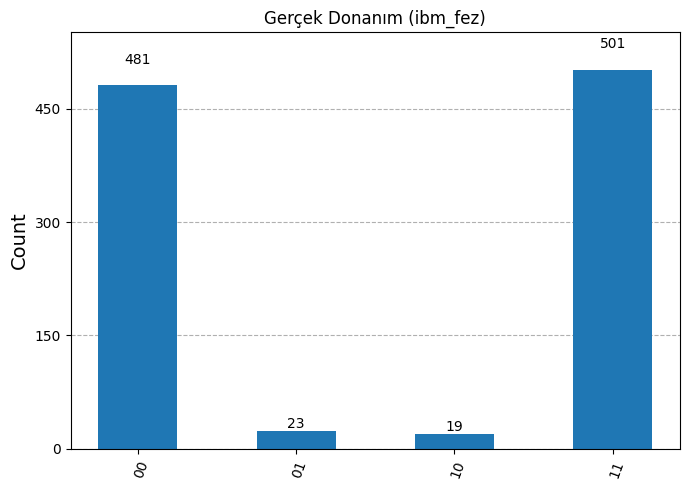

In [36]:
print("Gerçek Sonuçlar:", counts)
fig = plot_histogram(counts, title=f"Gerçek Donanım ({backend.name})", figsize=(7, 5))
display(fig)